In [1]:
# In this notebook we will discover the correct ways to initialize weights using xavier and he kernel_nit

In [2]:
# The setup is same as the notebook where we discussed how not to init weigths

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

import tensorflow 
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout,Dense,Input

In [4]:
X,y = make_moons(
                    n_samples=250,
                    noise = 0.22,
                    random_state = 12
)

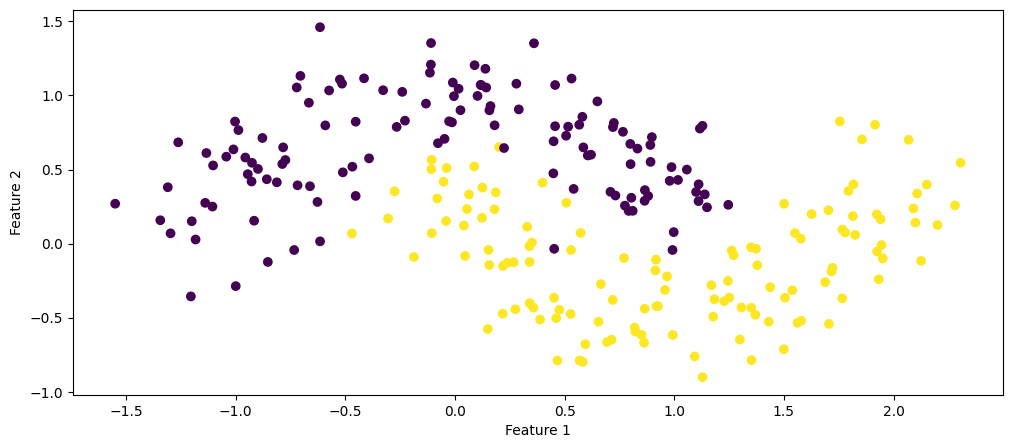

In [5]:
# Now lets plot this data to understand it better
plt.figure(figsize=(12,5))
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [6]:
# Split the dataset 
X_train ,X_test ,y_train ,y_test = train_test_split(
                                                        X,y,
                                                        test_size = 0.2,
                                                        random_state = 9
)

In [ ]:
# FOR all the cases we will use a special function which does all the steps for us but we we only pass the activation function
# used for the hidden layers and the output layer 

def weight_using_ki(af_hidden,af_output,n_layers,neurons_per_layer,loss_function,metric_score,kernal_init):
    
    model = Sequential()
    model.add(Input(shape=(X.shape[1],)))

    for _ in range(n_layers):
        model.add(Dense(neurons_per_layer,activation=af_hidden,kernel_initializer=kernal_init))
    
    model.add(Dense(1,activation=af_output))

    print(model.summary())


    print(f'The initial model weights set to  : \n {model.get_weights()} \n ')

    model.compile(loss=loss_function,optimizer='adam',metrics=metric_score)

    history = model.fit( X,y,epochs=100,validation_data = (X_test,y_test),verbose=0)

    # Plot the loss across epochs
    print(f'The model weights after fitting are  : \n {model.get_weights()} \n ')

    print(f'The loss across epoch is   :  \n ')
    
    plt.figure(figsize=(15,5))
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    print(f'The decision boundary made by the model :  \n ')

    plt.figure(figsize=(15,5))
    plot_decision_regions(X_test, y_test.ravel().astype(int), clf = model, legend=2)
    plt.show()



In [9]:
# Now we are actual initializing weights using such methods which will give feasible results upon activation functions
# As always we will be keeping the parametrs consistent and change the activation functions to look for the change in the model peformance
# We will do this process using weight initializer :  GlorotNormal and HeNormal 

# CASE 1 : Weight initializing using GlorotNormal

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[-0.08048372, -0.48380524,  0.10152084, -0.35568652, -0.17675996,
        -0.5720095 , -0.22331175, -0.6089543 ,  0.07064033,  0.65728587],
       [-0.18294357,  0.07622498,  0.19242868, -0.4038999 , -0.14452875,
        -0.2021289 , -0.03854002, -0.31769904,  0.6286161 , -0.1580312 ]],
      dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[-0.21696515,  0.23587163,  0.18300295, -0.3288838 ,  0.01583443,
         0.39812472,  0.40826818, -0.31684202, -0.00752384, -0.10416637],
       [ 0.1254729 , -0.33573645,  0.10832749, -0.45691437,  0.29718   ,
         0.2139017 ,  0.06751265,  0.2182602 , -0.70069337, -0.40066293],
       [-0.43965477, -0.49576792,  0.15471269, -0.41479936,  0.5218514 ,
        -0.46985245, -0.4394259 ,  0.18639348, -0.36403817,  0.20157935],
       [ 0.6031394 ,  0.10546919, -0.50100225,  0.3033117 , -0.20491056,
        -0.5769911 , -0.3467389 ,  0.60048056, -0.19025394, -

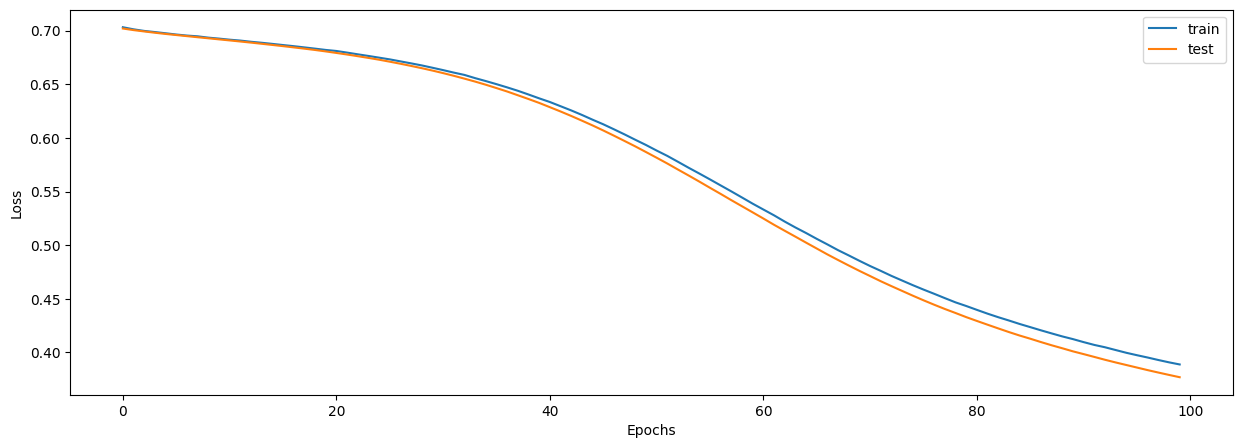

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 71s 3ms/step


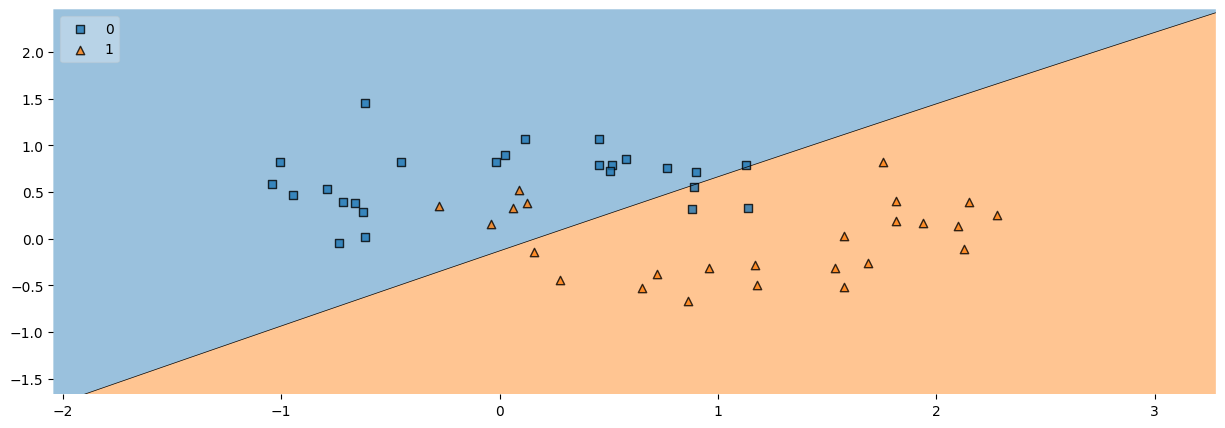

In [10]:
weight_using_ki(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'sigmoid',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy'],
                                kernal_init = 'glorot_normal'
        
)

In [ ]:
'''
What Initialization Can Do:
     It can prevent immediate explosion or total death of gradients at Epoch 0 
     (which is why Glorot is better than random large/small initialization).

What Initialization Cannot Do: 
    It cannot change the fundamental shape of the activation function. 
    It cannot stop a function with a maximum derivative of \(0.25\) from shrinking gradients during backpropagation.
    This realization is exactly what led the AI research community to largely abandon sigmoid for hidden layers in deep networks, 
    moving instead to tanh and relu.
    
'''

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[-0.35824862, -0.54793423, -0.00445347, -0.03302709,  0.9150637 ,
         0.15782912, -0.22391395,  0.36069545, -0.66334534,  0.25499222],
       [ 0.16329801, -0.160114  ,  0.92294586,  0.18393105,  0.2667985 ,
         0.297241  , -0.06144812,  0.57915777, -0.7779682 ,  0.23062855]],
      dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[-0.12044538, -0.4578554 ,  0.08065031, -0.15131962,  0.28516534,
        -0.1097897 ,  0.06080478,  0.62753665,  0.10470664,  0.11261573],
       [ 0.11871693, -0.23532192, -0.06488805, -0.42172238,  0.11371607,
         0.0088818 , -0.07848848, -0.22323209,  0.13501096,  0.15664802],
       [-0.14756863,  0.02818034, -0.18553056,  0.102876  , -0.05301327,
        -0.26117867,  0.5138114 ,  0.285124  , -0.13477574, -0.32386965],
       [ 0.42836785,  0.10478383, -0.45762146,  0.4378985 , -0.1839272 ,
         0.07433818, -0.6705128 , -0.16022035, -0.2986941 ,  

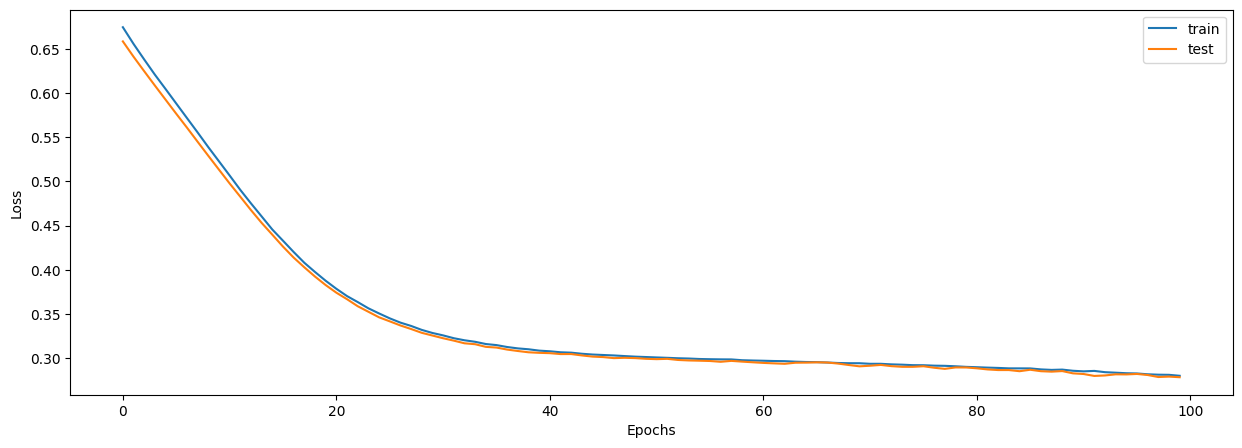

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 56s 2ms/step


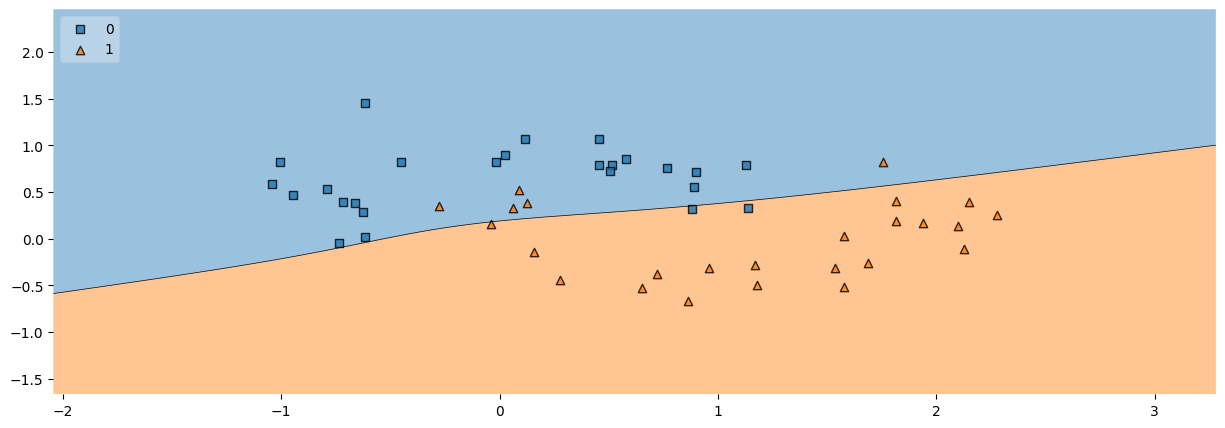

In [11]:
weight_using_ki(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'tanh',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy'],
                                kernal_init = 'glorot_normal'
        
)

In [ ]:
'''
Basically because of tanh function the derivative of the function near x = 0 is not 0.25 as sigmoid but 1 causing values closer to it to be of similar value
this causes the values that are multiplied together to be bigger and not cause the vanishing gradient problem as seen in sigmoid above

We see that the model performs reduces loss accelaritingly near 20 epochs whereas the sigmoid loss is gradually downwards after 60 epochs.

Also not to forget the boundary is more smoother because of the gradients and the model is properly learning patterns and is a curve not a rigid line .
'''